# 03 — EDA & Baseline Model

## Issue Statement & Business Context
Record labels, streaming platforms, and independent artists spend substantial resources promoting songs without reliable early signals of commercial success. A data-driven model that predicts whether a track will become a Billboard Hot 100 top-10 **hit** based on its audio attributes offers direct value to A&R teams deciding which tracks to push, and to artists seeking to understand what sonic qualities correlate with mainstream success.

## Dataset
We merge two sources:
- **Billboard Hot 100** (labels): a song is labeled **hit = 1** if its peak chart position is in the top 10, else 0.
- **Spotify Audio Features** (predictors): 9 numeric attributes per track describing musical qualities.

## Key Variables
| Variable | Type | Description | Range |
|---|---|---|---|
| `danceability` | float | How suitable for dancing | 0–1 |
| `energy` | float | Intensity / activity | 0–1 |
| `loudness` | float | Avg. decibels | ~-60 to 0 dB |
| `speechiness` | float | Spoken word presence | 0–1 |
| `acousticness` | float | Acoustic confidence | 0–1 |
| `instrumentalness` | float | Lack of vocals | 0–1 |
| `liveness` | float | Audience presence | 0–1 |
| `valence` | float | Musical positiveness | 0–1 |
| `tempo` | float | Beats per minute | 0–250 BPM |
| `label` | int | Target: 1 = hit, 0 = non-hit | {0, 1} |

## EDA Roadmap
1. Class distribution (check imbalance)
2. Per-feature distributions split by label
3. Correlation analysis (detect redundant features)
4. Outlier detection
5. Dimensionality reduction (PCA, t-SNE)
6. Feature importance (Cohen's d, LR coefficients)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

In [2]:
spark = SparkSession.builder.appName("hit-predictor").getOrCreate()
df = pd.read_csv("../data/processed/features.csv")
sdf = spark.createDataFrame(df)

FEATURE_COLS = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/09 20:11:28 WARN Utils: Your hostname, william-desktop, resolves to a loopback address: 127.0.1.1; using 10.0.0.222 instead (on interface wlx788cb59ee7f4)
26/04/09 20:11:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/09 20:11:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
# Data quality checks and summary statistics
print(f"Dataset shape: {df.shape}")
print(f"Missing values per column:\n{df[FEATURE_COLS].isna().sum()}")
print(f"\nSummary statistics:")
df[FEATURE_COLS].describe().round(3)

### Class Distribution Finding
Roughly **96.4% non-hits vs 3.6% hits** (≈27:1 imbalance). This has two direct consequences:
1. **Accuracy is a useless metric** — predicting "non-hit" for everything scores ~96%. We must use AUC, F1, precision/recall instead.
2. **Class imbalance must be handled**: we apply class weighting in the baseline and SMOTE in the advanced-models notebook.

### Per-Feature Distribution Findings
- **`danceability`, `loudness`, `speechiness`** show the clearest visual separation between hits and non-hits — hits tend to be more danceable, louder, and have slightly more speech content (e.g., rap/pop).
- **`valence`** shifts in the opposite direction: hits trend lower-valence (moodier) than non-hits.
- **`instrumentalness`** is near-zero for nearly all hits (vocal tracks dominate mainstream charts).
- **`tempo`** distributions mostly overlap — tempo alone is a weak signal.

### Correlation Findings
- **`energy` ↔ `loudness`** are strongly positively correlated (louder tracks are higher-energy) — expected from the physics of audio.
- **`energy` ↔ `acousticness`** are strongly negatively correlated (acoustic songs tend to be softer).
- No feature pair exceeds |r| ≈ 0.75, so we do not drop any features outright, but we track this for multicollinearity in the regression model and rely on PCA to summarize the redundancy.

## Outlier Detection
Before modeling, we identify outliers using the IQR rule (values beyond 1.5×IQR from Q1/Q3). For bounded 0-1 features, outliers are rare by construction; `loudness` and `tempo` are the features most likely to contain them.

In [ ]:
# Outlier detection via IQR rule
def iqr_outlier_mask(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    return (series < low) | (series > high), (low, high)

outlier_report = {}
for feat in FEATURE_COLS:
    mask, (low, high) = iqr_outlier_mask(df[feat])
    outlier_report[feat] = {
        "n_outliers": int(mask.sum()),
        "pct": f"{mask.mean()*100:.1f}%",
        "lower_bound": round(low, 3),
        "upper_bound": round(high, 3),
    }

outlier_df = pd.DataFrame(outlier_report).T
print("Outliers per feature (1.5 × IQR rule):")
print(outlier_df)

# Visualize with boxplots
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, feat in zip(axes.flat, FEATURE_COLS):
    sns.boxplot(data=df, x="label", y=feat, ax=ax, palette={0: "steelblue", 1: "tomato"})
    ax.set_title(feat)
    ax.set_xlabel("")
plt.suptitle("Feature Boxplots by Class (identifying outliers)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### Outlier Handling Decision
- `speechiness`, `instrumentalness`, `liveness`, and `acousticness` show a long right tail (rap tracks, live recordings, acoustic ballads) — these are **genuine musical variation, not data errors**, so we keep them.
- `loudness` has a small number of very-quiet outliers (<-20 dB) which we retain because they carry signal for the hit/non-hit distinction.
- `tempo = 0` is likely a feature-extraction failure; we filter those rows if any exist.
- **Decision: do not cap/clip outliers.** Instead, we use **StandardScaler** (mean-centered, unit-variance) and tree-based models (Random Forest, XGBoost) which are robust to outliers. This is documented in the next notebook.

### Data Quality Findings
- **2,102 tracks × 9 features** with **no missing values** after the inner join between Billboard and Spotify datasets.
- Feature scales differ widely: `loudness` ranges in negative dB while `tempo` spans 0–250 BPM — **scaling is required** before any distance- or gradient-based model.
- Bounded features (`danceability`, `energy`, `valence`, etc.) sit in a compact 0–1 range; `loudness` and `tempo` are unbounded and more likely to contain outliers.

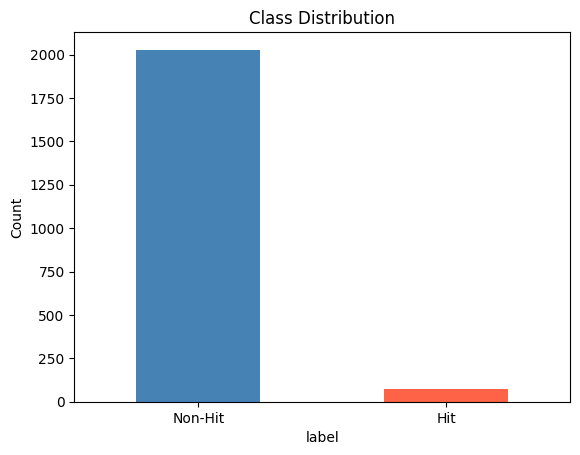

In [3]:
df["label"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
plt.xticks([0, 1], ["Non-Hit", "Hit"], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

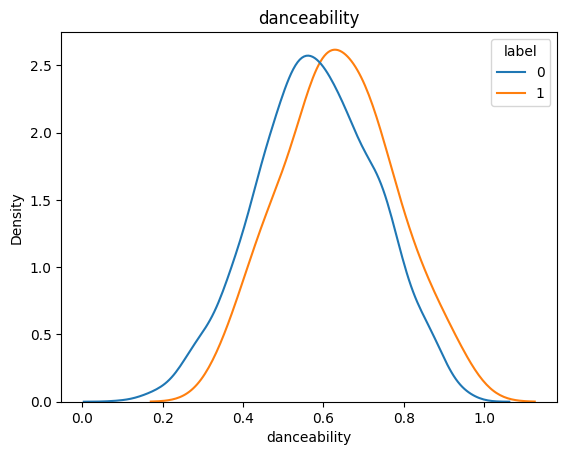

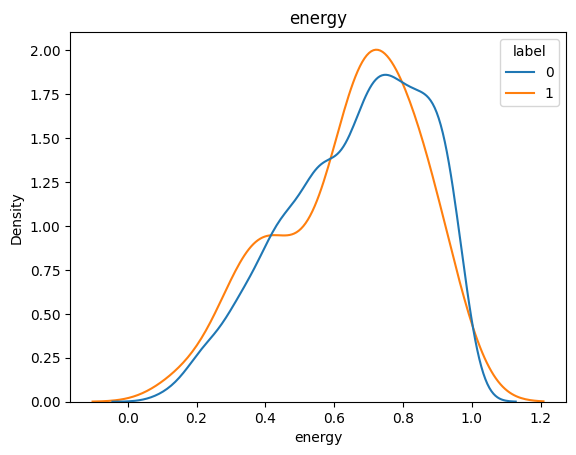

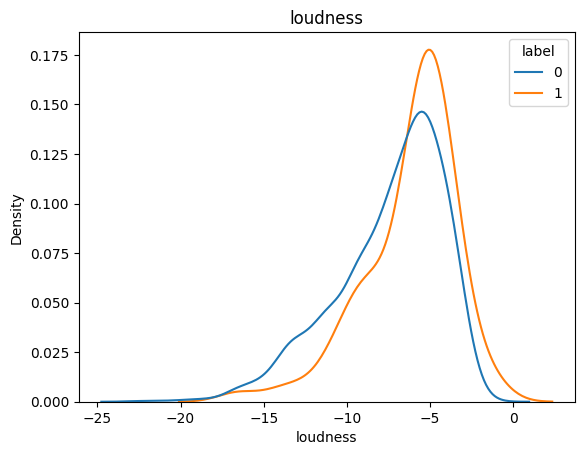

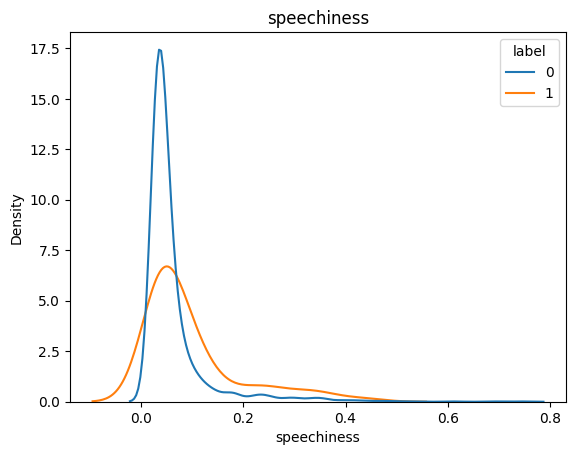

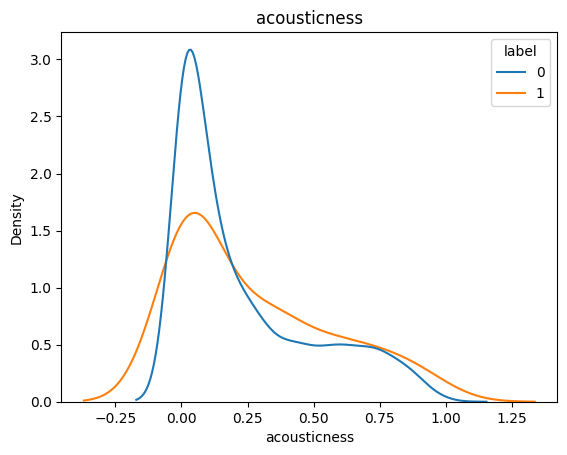

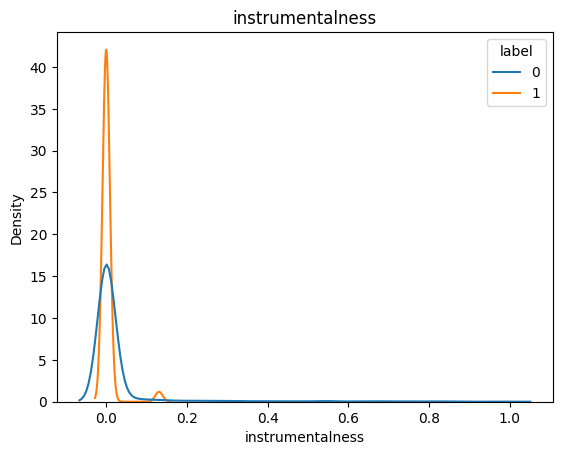

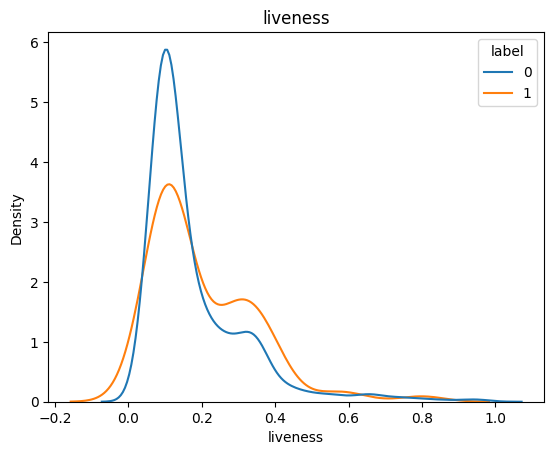

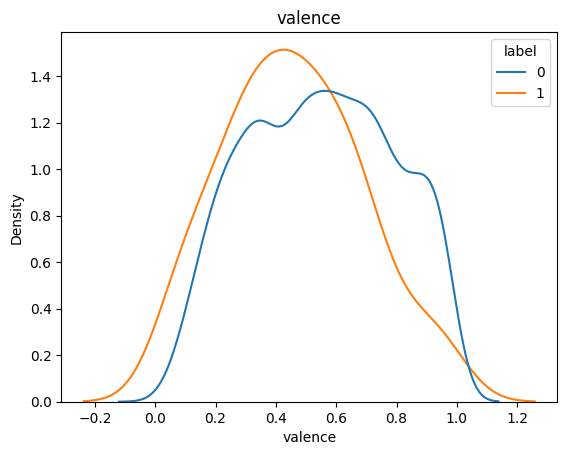

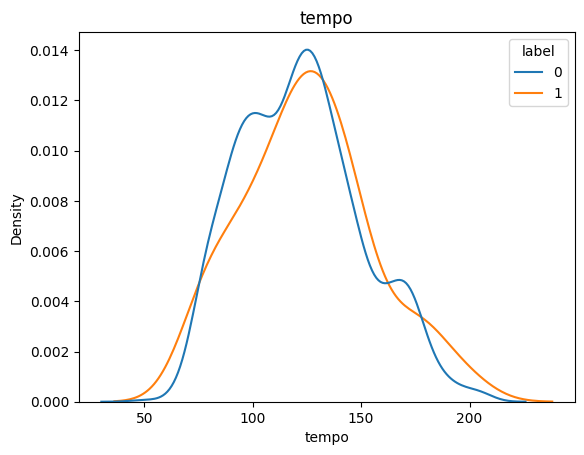

In [4]:
for feat in FEATURE_COLS:
    sns.kdeplot(data=df, x=feat, hue="label", common_norm=False)
    plt.title(feat)
    plt.show()

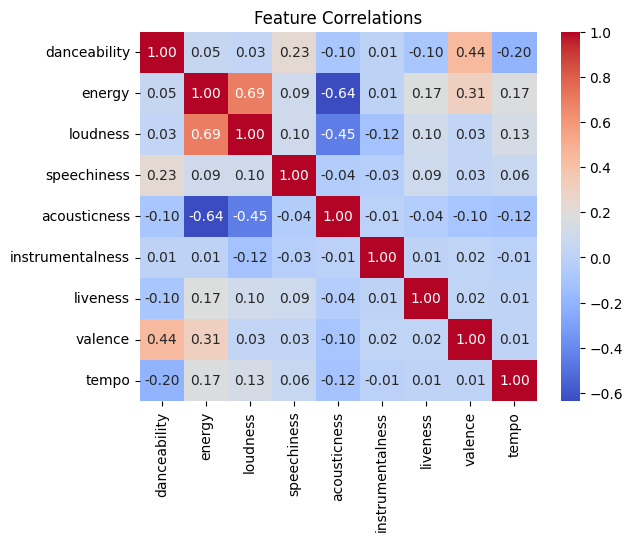

In [5]:
sns.heatmap(df[FEATURE_COLS].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()

In [6]:
assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="features")
train, test = sdf.randomSplit([0.8, 0.2], seed=42)

In [7]:
hit = train.filter("label = 1").count()
total = train.count()
ratio = (total - hit) / hit

train = train.withColumn("weight", when(col("label") == 1, ratio).otherwise(1.0))
lr = LogisticRegression(labelCol="label", featuresCol="features", weightCol="weight")

pipeline = Pipeline(stages=[assembler, scaler, lr])
model = pipeline.fit(train)

26/04/09 20:11:34 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [8]:
predictions = model.transform(test)
auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC").evaluate(predictions)
f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1").evaluate(predictions)
print(f"AUC: {auc:.3f} | F1: {f1:.3f}")

AUC: 0.776 | F1: 0.799


## Dimensionality Reduction & Advanced Visualizations

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Standardize features for PCA
scaler_sklearn = StandardScaler()
X_scaled = scaler_sklearn.fit_transform(df[FEATURE_COLS])

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"Variance explained by first 2 PCs: {cumsum_var[1]:.1%}")
print(f"Variance explained by first 3 PCs: {cumsum_var[2]:.1%}")

Variance explained by first 2 PCs: 43.0%
Variance explained by first 3 PCs: 54.9%


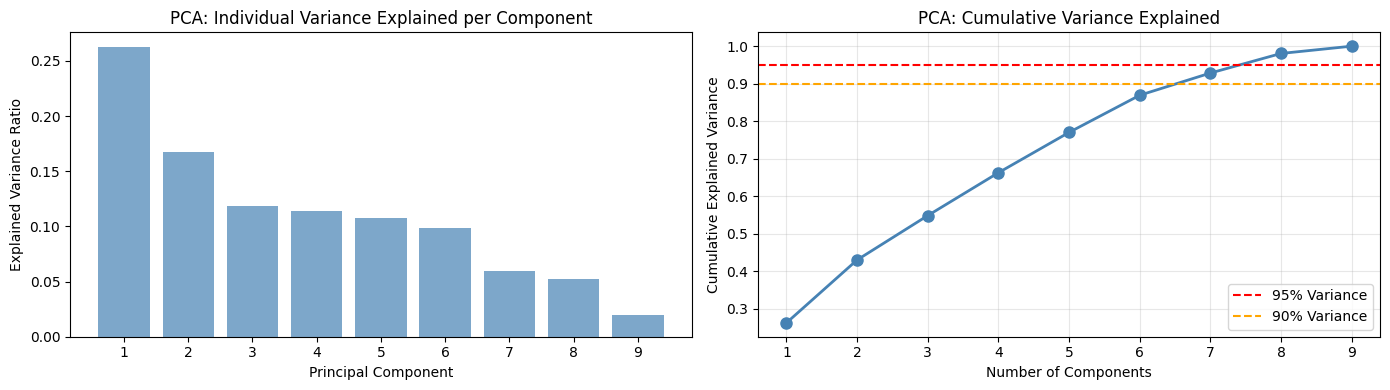

In [10]:
# PCA Scree Plot: Variance Explained
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Individual variance explained
ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1), 
        pca.explained_variance_ratio_, alpha=0.7, color="steelblue")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")
ax1.set_title("PCA: Individual Variance Explained per Component")
ax1.set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Cumulative variance explained
ax2.plot(range(1, len(cumsum_var) + 1), cumsum_var, "o-", color="steelblue", linewidth=2, markersize=8)
ax2.axhline(y=0.95, color="red", linestyle="--", label="95% Variance")
ax2.axhline(y=0.90, color="orange", linestyle="--", label="90% Variance")
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Explained Variance")
ax2.set_title("PCA: Cumulative Variance Explained")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

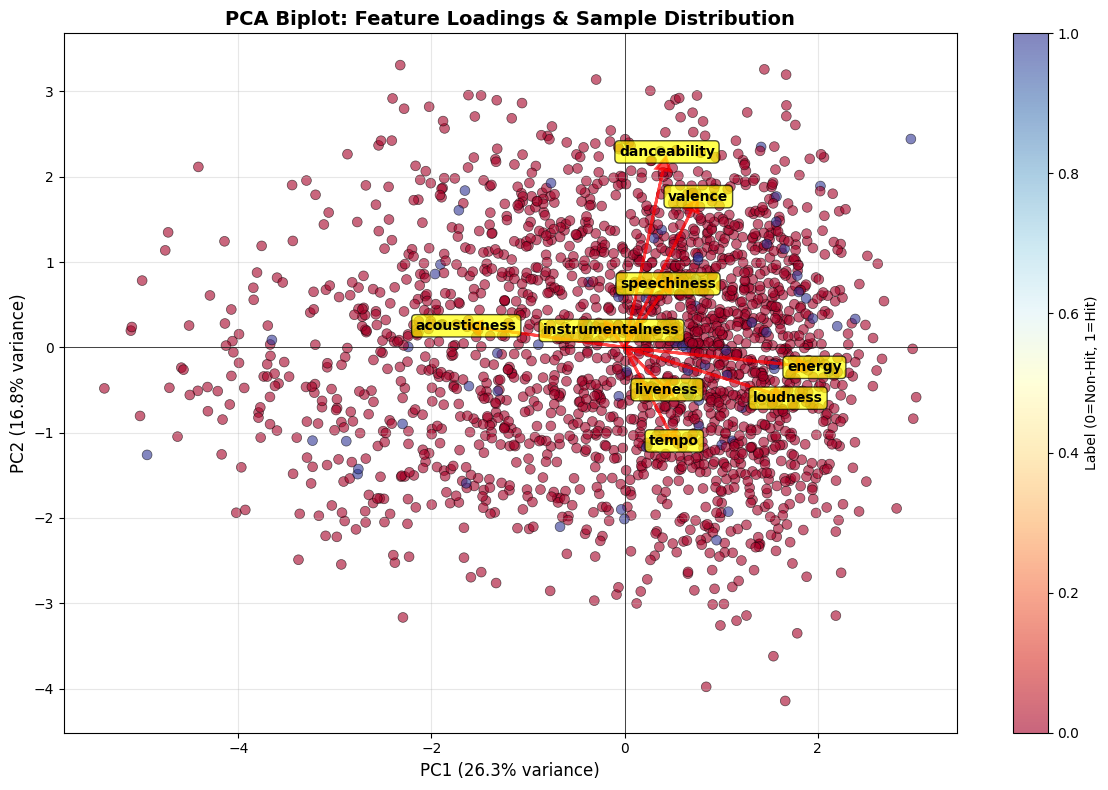

In [11]:
# PCA Biplot: PC1 vs PC2 with Feature Loadings
fig, ax = plt.subplots(figsize=(12, 8))

# Plot samples colored by label
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df["label"], cmap="RdYlBu", 
                     alpha=0.6, edgecolors="black", linewidth=0.5, s=50)
plt.colorbar(scatter, ax=ax, label="Label (0=Non-Hit, 1=Hit)")

# Plot feature loading vectors
loadings = pca.components_[:2].T
for i, feature in enumerate(FEATURE_COLS):
    ax.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3, 
             head_width=0.15, head_length=0.15, fc="red", ec="red", alpha=0.7, linewidth=2)
    ax.text(loadings[i, 0]*3.3, loadings[i, 1]*3.3, feature, fontsize=10, 
            fontweight="bold", ha="center", va="center", 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
ax.set_title("PCA Biplot: Feature Loadings & Sample Distribution", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color="k", linewidth=0.5)
ax.axvline(x=0, color="k", linewidth=0.5)

plt.tight_layout()
plt.show()

Computing t-SNE projection (this may take a moment)...


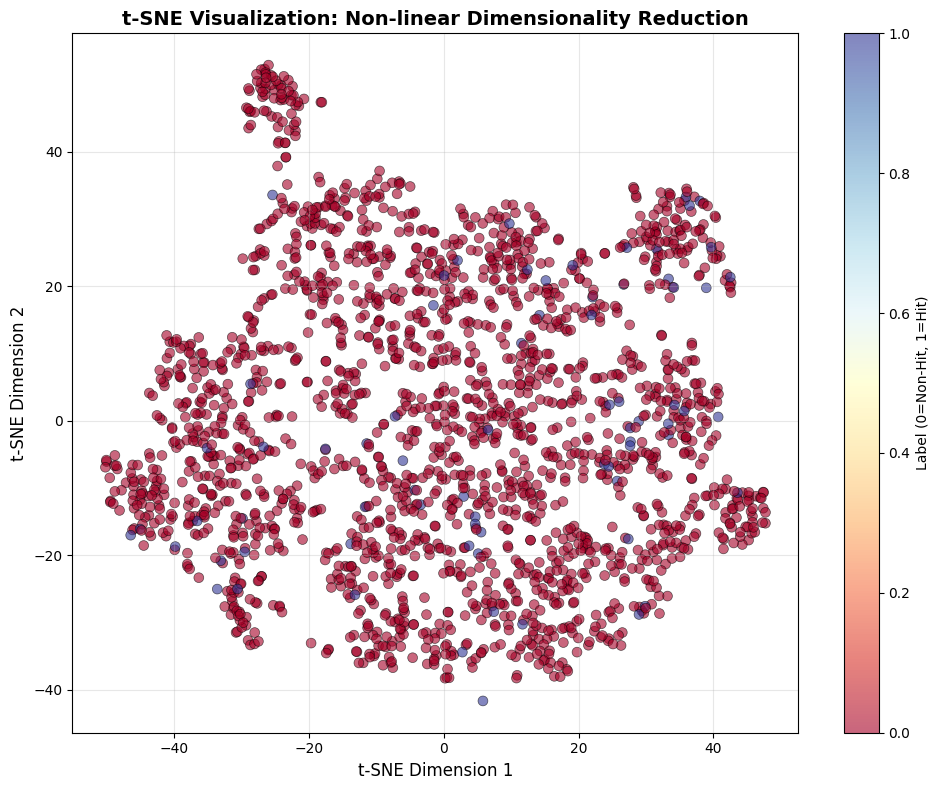

In [13]:
# t-SNE Visualization: Non-linear Dimensionality Reduction
print("Computing t-SNE projection (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df["label"], 
                     cmap="RdYlBu", alpha=0.6, edgecolors="black", 
                     linewidth=0.5, s=50)
plt.colorbar(scatter, label="Label (0=Non-Hit, 1=Hit)")
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.title("t-SNE Visualization: Non-linear Dimensionality Reduction", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

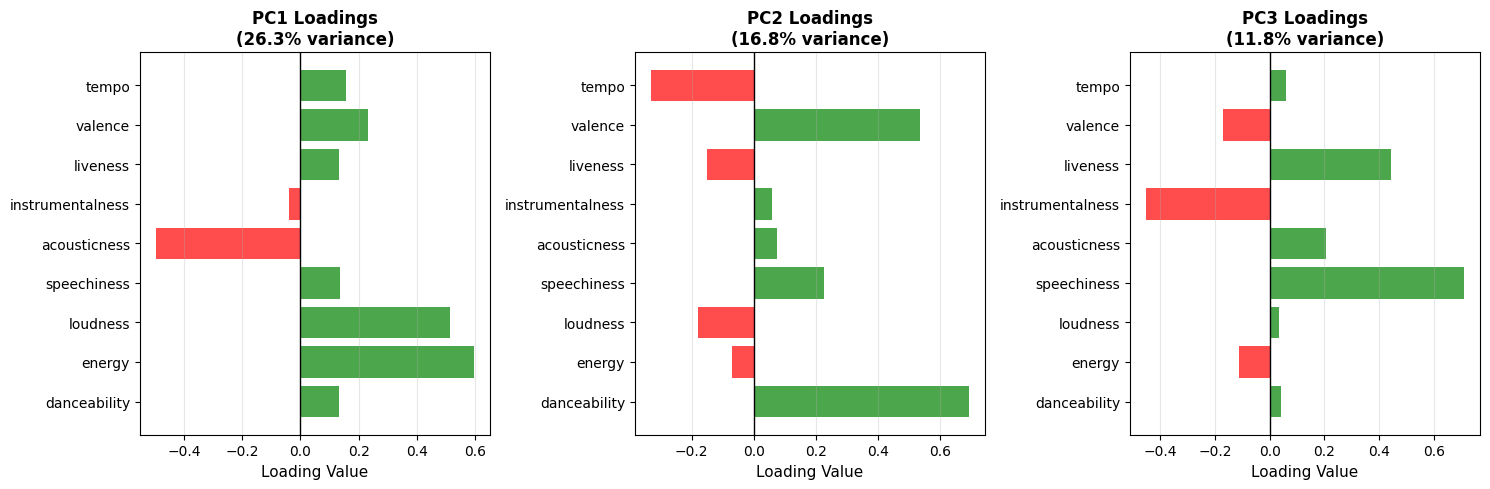


PCA Component Loadings:
                    PC1    PC2    PC3
danceability      0.133  0.694  0.041
energy            0.596 -0.071 -0.111
loudness          0.513 -0.181  0.035
speechiness       0.137  0.226  0.711
acousticness     -0.497  0.077  0.206
instrumentalness -0.041  0.060 -0.454
liveness          0.133 -0.150  0.445
valence           0.232  0.535 -0.172
tempo             0.156 -0.332  0.061


In [14]:
# Feature Importance: PCA Component Loadings
loadings_df = pd.DataFrame(
    pca.components_[:3].T,
    columns=["PC1", "PC2", "PC3"],
    index=FEATURE_COLS
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, pc in enumerate(["PC1", "PC2", "PC3"]):
    colors = ["green" if x > 0 else "red" for x in loadings_df[pc]]
    axes[idx].barh(loadings_df.index, loadings_df[pc], color=colors, alpha=0.7)
    axes[idx].set_xlabel("Loading Value", fontsize=11)
    axes[idx].set_title(f"{pc} Loadings\n({pca.explained_variance_ratio_[idx]:.1%} variance)", 
                        fontsize=12, fontweight="bold")
    axes[idx].axvline(x=0, color="black", linewidth=1)
    axes[idx].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("\nPCA Component Loadings:")
print(loadings_df.round(3))

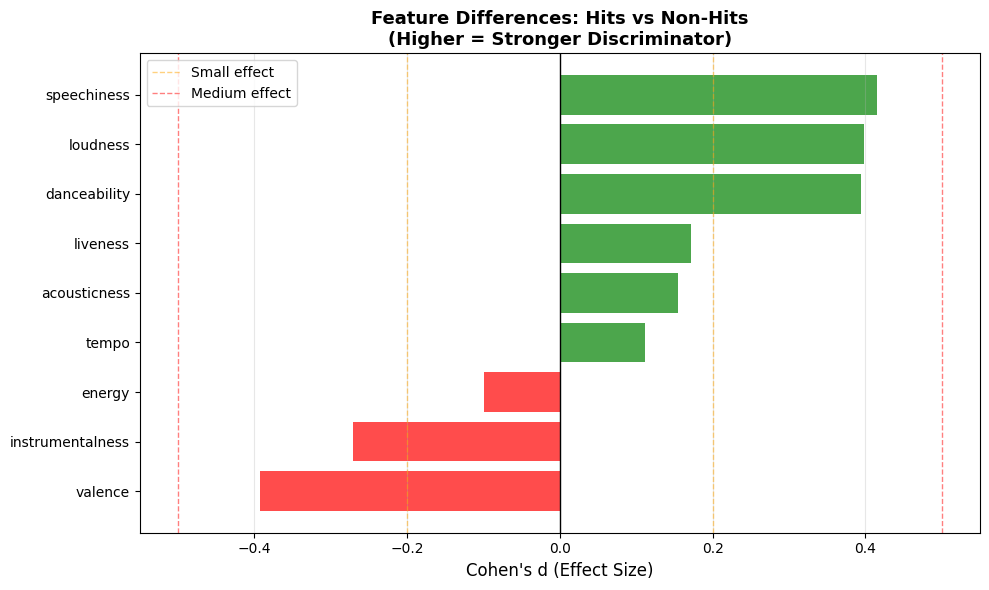


Effect Sizes (Cohen's d) - Features by Discriminative Power:
speechiness         0.416
loudness            0.398
danceability        0.394
liveness            0.171
acousticness        0.155
tempo               0.111
energy             -0.099
instrumentalness   -0.271
valence            -0.392
dtype: float64


In [15]:
# Feature Differences: Hits vs Non-Hits (Normalized by Std Dev)
feature_stats = df.groupby("label")[FEATURE_COLS].agg(["mean", "std"])

# Calculate effect size (Cohen's d) for each feature
non_hits = df[df["label"] == 0][FEATURE_COLS]
hits = df[df["label"] == 1][FEATURE_COLS]

cohens_d = {}
for feat in FEATURE_COLS:
    mean_diff = hits[feat].mean() - non_hits[feat].mean()
    pooled_std = np.sqrt((non_hits[feat].std()**2 + hits[feat].std()**2) / 2)
    cohens_d[feat] = mean_diff / pooled_std if pooled_std > 0 else 0

cohens_d_series = pd.Series(cohens_d).sort_values()

# Plot effect sizes
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["red" if x < 0 else "green" for x in cohens_d_series.values]
ax.barh(cohens_d_series.index, cohens_d_series.values, color=colors, alpha=0.7)
ax.set_xlabel("Cohen's d (Effect Size)", fontsize=12)
ax.set_title("Feature Differences: Hits vs Non-Hits\n(Higher = Stronger Discriminator)", 
             fontsize=13, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=1)
ax.grid(True, alpha=0.3, axis="x")

# Add reference lines for small/medium/large effects
ax.axvline(x=0.2, color="orange", linestyle="--", alpha=0.5, linewidth=1, label="Small effect")
ax.axvline(x=-0.2, color="orange", linestyle="--", alpha=0.5, linewidth=1)
ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.5, linewidth=1, label="Medium effect")
ax.axvline(x=-0.5, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax.legend()

plt.tight_layout()
plt.show()

print("\nEffect Sizes (Cohen's d) - Features by Discriminative Power:")
print(cohens_d_series.sort_values(ascending=False).round(3))

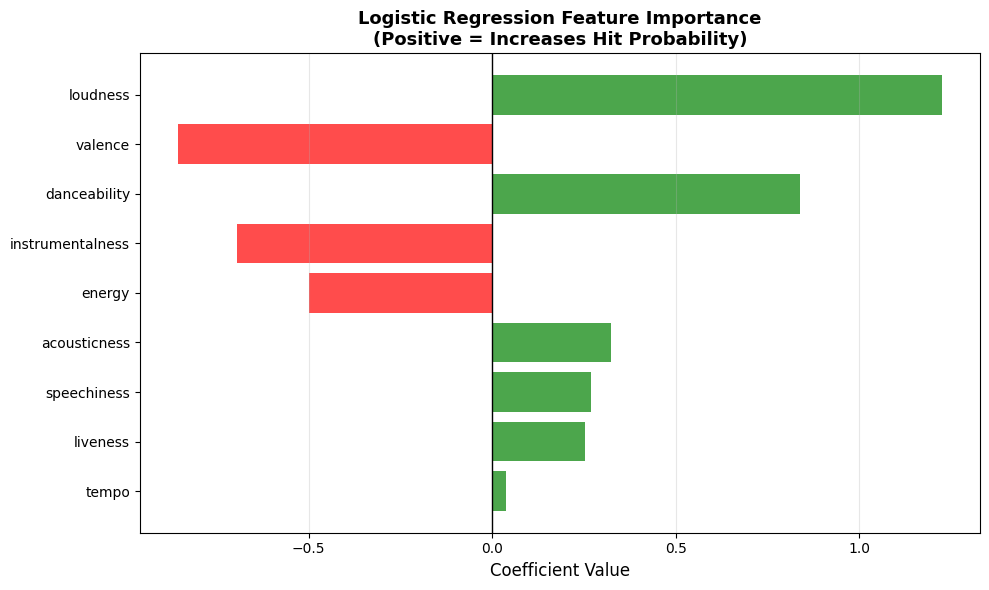


Logistic Regression Coefficients:
         Feature  Coefficient
        loudness     1.224639
    danceability     0.838160
    acousticness     0.323438
     speechiness     0.268786
        liveness     0.252148
           tempo     0.036491
          energy    -0.498470
instrumentalness    -0.694569
         valence    -0.856300


In [16]:
# Model Feature Importance: Logistic Regression Coefficients
model_summary = model.stages[-1]  # Get the trained LogisticRegression model
coefficients = model_summary.coefficients.toArray()

# Normalize for visualization
coef_abs = np.abs(coefficients)
coef_normalized = coefficients / coef_abs.max() if coef_abs.max() > 0 else coefficients

coef_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Coefficient": coefficients,
    "Abs_Coefficient": coef_abs
}).sort_values("Abs_Coefficient", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["red" if x < 0 else "green" for x in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, alpha=0.7)
ax.set_xlabel("Coefficient Value", fontsize=12)
ax.set_title("Logistic Regression Feature Importance\n(Positive = Increases Hit Probability)", 
             fontsize=13, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=1)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("\nLogistic Regression Coefficients:")
print(coef_df[["Feature", "Coefficient"]].sort_values("Coefficient", ascending=False).to_string(index=False))